epoch=0, loss=28.1794, w=-0.6338, b=-0.3452
epoch=10, loss=0.5198, w=3.0019, b=-1.7332
epoch=20, loss=0.0818, w=3.4508, b=-1.9300
epoch=30, loss=0.0748, w=3.5065, b=-1.9570
epoch=40, loss=0.0747, w=3.5135, b=-1.9607
epoch=50, loss=0.0747, w=3.5144, b=-1.9612
epoch=60, loss=0.0747, w=3.5145, b=-1.9612
epoch=70, loss=0.0747, w=3.5145, b=-1.9612
epoch=80, loss=0.0747, w=3.5145, b=-1.9612
epoch=90, loss=0.0747, w=3.5145, b=-1.9612


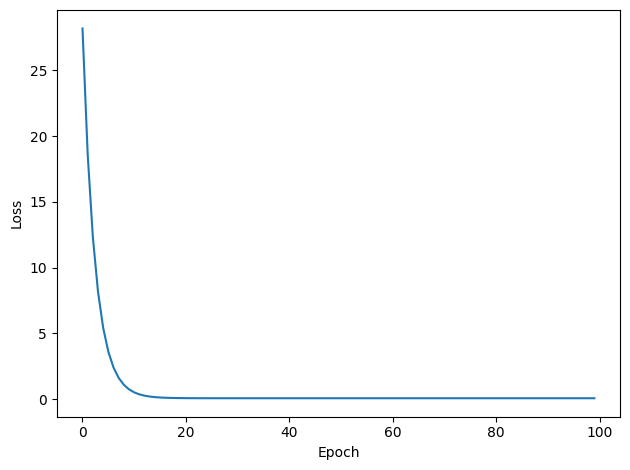

In [9]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

n = 200
X = torch.randn(n, 1)
true_w = torch.tensor([[3.5]])
true_b = torch.tensor([-2.0])
y = X @ true_w + true_b + 0.3 * torch.randn(n, 1)

w = torch.randn(1, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.1
epochs = 100
losses = []

for epoch in range(epochs):
    y_pred = X @ w + b
    loss = ((y_pred - y) ** 2).mean()
    loss.backward()
    
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()
    
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"epoch={epoch}, loss={loss.item():.4f}, w={w.item():.4f}, b={b.item():.4f}")

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()